# 05 - MLP Classifier

## Objective
Train a supervised deep-learning classifier for the credit-card fraud task and compare its final behaviour with the existing Random Forest and autoencoder evidence.

- This MLP consumes the same 30 tabular transaction features used by the corrected supervised models.
- It is a better fit for this dataset than an LSTM because the dataset does not provide per-cardholder transaction sequences.
- Architecture and decision-threshold choices are made using validation data only.
- The test split is reserved for the final selected MLP evaluation.

In [29]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input

project_root = Path.cwd().parent if Path.cwd().name == "notebooks_corrections" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.evaluation import (
    DEFAULT_THRESHOLD_GRID,
    evaluate_binary_scores,
    save_confusion_matrix_plot,
    save_roc_pr_curves,
    select_best_result,
    tune_binary_thresholds,
)
from src.preprocessing import preprocess_creditcard_dataset

RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)

## Load the Corrected Split

The MLP uses the same duplicate-cleaned and train-only-scaled dataset artifact as notebooks 03 and 04. The validation split is used for architecture comparison, early stopping, and threshold selection.

In [30]:
data_path = project_root / "outputs" / "results_corrected" / "creditcard_cleaned.pkl"
raw_data_path = project_root / "data" / "creditcard.csv"


results_dir = project_root / "outputs" / "results_corrected"
figures_dir = project_root / "outputs" / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

try:
    data = joblib.load(data_path)
    print("Loaded corrected split artifact:", data_path)
except NotImplementedError as exc:
    print("The active notebook kernel cannot unpickle the saved pandas split artifact.")
    print("Rebuilding the corrected split from raw CSV in memory with this kernel instead.")
    print("Original load error:", exc)
    if not raw_data_path.exists():
        raise FileNotFoundError(
            f"Raw dataset not found at {raw_data_path}. Use the project .venv kernel "
            "or place creditcard.csv in data/."
        ) from exc
    data = preprocess_creditcard_dataset(raw_data_path)
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

print("X_train:", X_train.shape, "fraud:", int(y_train.sum()))
print("X_val:", X_val.shape, "fraud:", int(y_val.sum()))
print("X_test:", X_test.shape, "fraud:", int(y_test.sum()))

Loaded corrected split artifact: d:\Development_Studio\Python_Studio\ACML\Project\outputs\results_corrected\creditcard_cleaned.pkl
X_train: (198608, 30) fraud: 331
X_val: (42559, 30) fraud: 71
X_test: (42559, 30) fraud: 71


## Why an MLP?

A dense MLP is a supervised neural classifier for tabular features. It can learn non-linear feature interactions in the anonymised PCA features plus scaled `Time` and `Amount`, while keeping the input representation faithful to the available dataset.

The model is trained with class weights because fraud transactions are rare. For class \(c\), the balanced weight used by scikit-learn is:

\[
w_c = \frac{n}{K n_c},
\]

where \(n\) is the number of training samples, \(K\) is the number of classes, and \(n_c\) is the number of training samples in class \(c\). The loss remains binary cross-entropy, but fraud errors receive a much larger weight during optimisation.

In [31]:
classes = np.array([0, 1])
balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)
class_weight = {int(label): float(weight) for label, weight in zip(classes, balanced_weights)}
class_weight

{0: 0.5008346908617742, 1: 300.012084592145}

## MLP Configurations and Helpers

The experiment set varies capacity, dropout, and learning rate. The wide model is tested at two learning rates so validation behaviour can show whether a smaller optimiser step helps the imbalanced classifier.

In [32]:
MLP_CONFIGS = [
    {
        "name": "MLP_dense_64_32_dropout_0.2_lr_1e-3",
        "hidden_units": (64, 32),
        "dropout_rate": 0.2,
        "learning_rate": 1e-3,
    },
    {
        "name": "MLP_dense_128_64_32_dropout_0.3_lr_1e-3",
        "hidden_units": (128, 64, 32),
        "dropout_rate": 0.3,
        "learning_rate": 1e-3,
    },
    {
        "name": "MLP_dense_128_64_32_dropout_0.3_lr_5e-4",
        "hidden_units": (128, 64, 32),
        "dropout_rate": 0.3,
        "learning_rate": 5e-4,
    },
]


def build_mlp(input_dim, hidden_units, dropout_rate, learning_rate):
    model = Sequential(name="fraud_mlp")
    model.add(Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )
    return model


def positive_scores(model, X):
    return model.predict(X, verbose=0).reshape(-1)


def display_saved_figure(figure_path, figsize=(12, 5)):
    image = plt.imread(figure_path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.axis("off")
    plt.show()


pd.DataFrame(MLP_CONFIGS)

,name,hidden_units,dropout_rate,learning_rate
0,MLP_dense_64_32_dropout_0.2_lr_1e-3,"(64, 32)",0.2,0.0010
1,MLP_dense_128_64_32_dropout_0.3_lr_1e-3,"(128, 64, 32)",0.3,0.0010
2,MLP_dense_128_64_32_dropout_0.3_lr_5e-4,"(128, 64, 32)",0.3,0.0005


## Train Candidate MLPs

Each configuration is trained with early stopping monitored on validation PR-AUC. After training, the probability scores on the validation split are evaluated over the same threshold grid used for the corrected supervised models.

In [33]:
trained_mlps = {}
histories = {}
validation_scores = {}
threshold_frames = []

for config in MLP_CONFIGS:
    print("Training:", config["name"])
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = build_mlp(
        input_dim=X_train.shape[1],
        hidden_units=config["hidden_units"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"],
    )

    early_stop = EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=1024,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=1,
    )

    model_name = config["name"]
    val_scores = positive_scores(model, X_val)
    trained_mlps[model_name] = model
    histories[model_name] = history
    validation_scores[model_name] = val_scores
    threshold_frames.append(
        tune_binary_thresholds(model_name, y_val, val_scores, DEFAULT_THRESHOLD_GRID)
    )

mlp_validation_threshold_df = pd.concat(threshold_frames, ignore_index=True)
mlp_validation_threshold_df.sort_values(["F1", "PR_AUC", "Recall"], ascending=False).head(15)

Training: MLP_dense_64_32_dropout_0.2_lr_1e-3
Epoch 1/40
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2941 - pr_auc: 0.6324 - roc_auc: 0.9373 - val_loss: 0.1431 - val_pr_auc: 0.7144 - val_roc_auc: 0.9706
Epoch 2/40
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1806 - pr_auc: 0.6444 - roc_auc: 0.9728 - val_loss: 0.1157 - val_pr_auc: 0.6864 - val_roc_auc: 0.9785
Epoch 3/40
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1412 - pr_auc: 0.6618 - roc_auc: 0.9871 - val_loss: 0.1015 - val_pr_auc: 0.6870 - val_roc_auc: 0.9774
Epoch 4/40
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1288 - pr_auc: 0.6058 - roc_auc: 0.9899 - val_loss: 0.0939 - val_pr_auc: 0.6891 - val_roc_auc: 0.9754
Epoch 5/40
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1242 - pr_auc: 0.6616 - roc_auc: 0.9906 - val_loss: 0.0922 - val_pr_auc: 0.6816 - val_roc_auc: 0.9760
Epoch 6/40
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1188 - pr_auc: 0.6716 - roc_auc: 0.9911 - val_loss: 0.0872 - val_pr_auc:

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
18,MLP_dense_64_32_dropout_0.2_lr_1e-3,0.95,0.786667,0.830986,0.808219,0.970977,0.707532,42472,16,12,59
56,MLP_dense_128_64_32_dropout_0.3_lr_5e-4,0.95,0.722892,0.845070,0.779221,0.977374,0.700247,42465,23,11,60
17,MLP_dense_64_32_dropout_0.2_lr_1e-3,0.90,0.685393,0.859155,0.762500,0.970977,0.707532,42460,28,10,61
37,MLP_dense_128_64_32_dropout_0.3_lr_1e-3,0.95,0.678161,0.830986,0.746835,0.978327,0.710767,42460,28,12,59
36,MLP_dense_128_64_32_dropout_0.3_lr_1e-3,0.90,0.544643,0.859155,0.666667,0.978327,0.710767,42437,51,10,61
55,MLP_dense_128_64_32_dropout_0.3_lr_5e-4,0.90,0.545455,0.845070,0.662983,0.977374,0.700247,42438,50,11,60
16,MLP_dense_64_32_dropout_0.2_lr_1e-3,0.85,0.455224,0.859155,0.595122,0.970977,0.707532,42415,73,10,61
35,MLP_dense_128_64_32_dropout_0.3_lr_1e-3,0.85,0.421769,0.873239,0.568807,0.978327,0.710767,42403,85,9,62
54,MLP_dense_128_64_32_dropout_0.3_lr_5e-4,0.85,0.303483,0.859155,0.448529,0.977374,0.700247,42348,140,10,61
34,MLP_dense_128_64_32_dropout_0.3_lr_1e-3,0.80,0.298077,0.873239,0.444444,0.978327,0.710767,42342,146,9,62


## Select the MLP on Validation Data

The model-threshold pair with the best validation F1-score is selected. PR-AUC and recall are used as secondary sorting criteria when F1 values tie.

In [34]:
best_validation_row = select_best_result(mlp_validation_threshold_df)
best_mlp_name = best_validation_row["Model"]
best_mlp_threshold = float(best_validation_row["Threshold"])
best_mlp = trained_mlps[best_mlp_name]
best_mlp_history = histories[best_mlp_name]
best_mlp_config = next(config for config in MLP_CONFIGS if config["name"] == best_mlp_name)

print("Selected MLP:", best_mlp_name)
print("Selected validation threshold:", best_mlp_threshold)
pd.DataFrame([best_validation_row])

Selected MLP: MLP_dense_64_32_dropout_0.2_lr_1e-3
Selected validation threshold: 0.95


,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
18,MLP_dense_64_32_dropout_0.2_lr_1e-3,0.95,0.786667,0.830986,0.808219,0.970977,0.707532,42472,16,12,59


## Selected MLP Training Curve

Loss and PR-AUC are shown together because the class-weighted optimisation loss and the practical minority-class ranking behaviour do not always improve at the same rate.

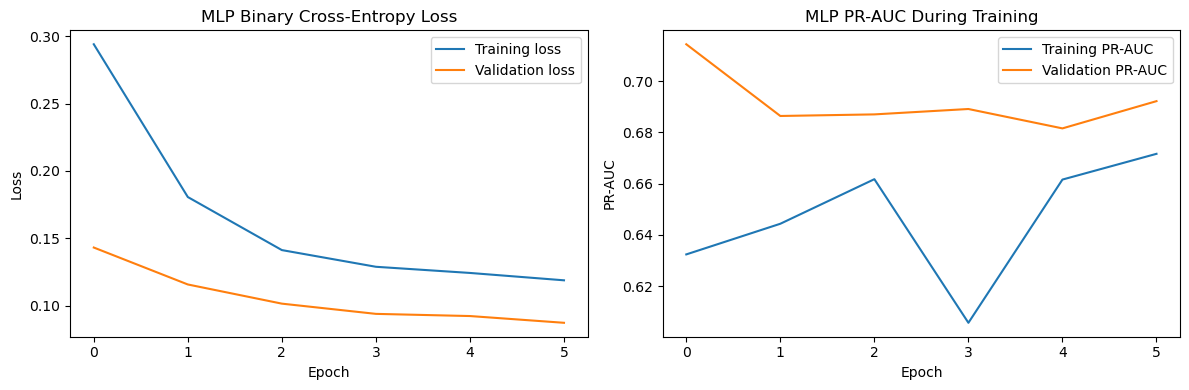

Saved: d:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\mlp_selected_model_training_curve.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(best_mlp_history.history["loss"], label="Training loss")
axes[0].plot(best_mlp_history.history["val_loss"], label="Validation loss")
axes[0].set_title("MLP Binary Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(best_mlp_history.history["pr_auc"], label="Training PR-AUC")
axes[1].plot(best_mlp_history.history["val_pr_auc"], label="Validation PR-AUC")
axes[1].set_title("MLP PR-AUC During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PR-AUC")
axes[1].legend()

fig.tight_layout()
mlp_training_curve_path = figures_dir / "mlp_selected_model_training_curve.png"
fig.savefig(mlp_training_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", mlp_training_curve_path)

## Final Test Evaluation

Only the selected MLP and its validation-selected threshold are evaluated on the held-out test set.

In [36]:
test_scores = positive_scores(best_mlp, X_test)
mlp_test_df = pd.DataFrame(
    [evaluate_binary_scores(best_mlp_name, y_test, test_scores, best_mlp_threshold)]
)
test_pred = (test_scores >= best_mlp_threshold).astype(int)

print(f"===== {best_mlp_name} | threshold = {best_mlp_threshold:.3f} =====")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred, labels=[0, 1]))
mlp_test_df

===== MLP_dense_64_32_dropout_0.2_lr_1e-3 | threshold = 0.950 =====
              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9997     42488
           1     0.8209    0.7746    0.7971        71

    accuracy                         0.9993     42559
   macro avg     0.9103    0.8872    0.8984     42559
weighted avg     0.9993    0.9993    0.9993     42559

Confusion matrix:
[[42476    12]
 [   16    55]]


,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,MLP_dense_64_32_dropout_0.2_lr_1e-3,0.95,0.820896,0.774648,0.797101,0.945893,0.65359,42476,12,16,55


## Save and Display Report Figures

These figures document the final MLP ranking behaviour and final thresholded decisions.

Saved: d:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\mlp_selected_model_roc_pr_curves.png


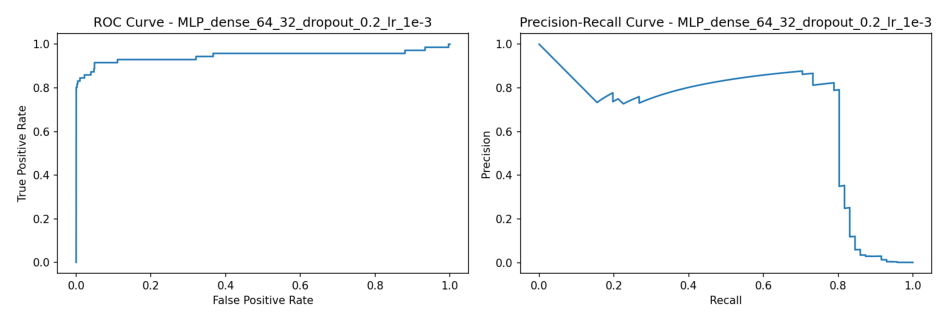

Saved: d:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\mlp_selected_model_confusion_matrix.png


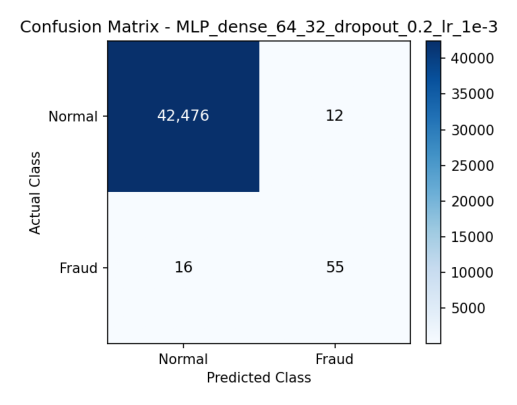

In [37]:
saved_mlp_figures = [
    save_roc_pr_curves(
        y_test,
        test_scores,
        best_mlp_name,
        figures_dir,
        "mlp_selected_model",
    ),
    save_confusion_matrix_plot(
        y_test,
        test_scores,
        best_mlp_threshold,
        best_mlp_name,
        figures_dir,
        "mlp_selected_model",
    ),
]

for figure_path in saved_mlp_figures:
    print("Saved:", figure_path)
    display_saved_figure(figure_path)

## Compare with Existing Final Models

If the Random Forest and autoencoder final CSV files exist, this table makes the additional supervised deep model easy to compare before updating the report.

In [38]:
comparison_frames = [mlp_test_df]
for result_name in ["baseline_test_results.csv", "autoencoder_test_results.csv"]:
    result_path = results_dir / result_name
    if result_path.exists():
        comparison_frames.append(pd.read_csv(result_path))

final_comparison_df = pd.concat(comparison_frames, ignore_index=True, sort=False)
comparison_columns = [
    "Model", "Threshold", "Precision", "Recall", "F1",
    "ROC_AUC", "PR_AUC", "TN", "FP", "FN", "TP",
]
final_comparison_df[[column for column in comparison_columns if column in final_comparison_df.columns]]

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,MLP_dense_64_32_dropout_0.2_lr_1e-3,0.950000,0.820896,0.774648,0.797101,0.945893,0.653590,42476,12,16,55
1,Random Forest - balanced,0.350000,0.925926,0.704225,0.800000,0.941271,0.815670,42484,4,21,50
2,AE_bottleneck_6_dropout_0.2,3.613886,0.114650,0.760563,0.199262,0.935140,0.192112,42071,417,17,54


## Save MLP Artifacts

The MLP saves its validation threshold table, final test metrics, selected model, and selection metadata separately from the existing Random Forest and autoencoder artifacts.

In [39]:
mlp_validation_threshold_df.to_csv(
    results_dir / "mlp_validation_threshold_tuning.csv",
    index=False,
)
mlp_test_df.to_csv(results_dir / "mlp_test_results.csv", index=False)
best_mlp.save(results_dir / "mlp_best_model.keras")

joblib.dump(
    {
        "best_mlp_name": best_mlp_name,
        "best_mlp_threshold": best_mlp_threshold,
        "best_mlp_config": best_mlp_config,
        "best_mlp_validation_row": best_validation_row.to_dict(),
        "training_curve_path": str(mlp_training_curve_path),
    },
    results_dir / "mlp_selection.pkl",
)

print("Saved MLP validation results, final test results, model, and selection metadata.")

Saved MLP validation results, final test results, model, and selection metadata.


## Report Notes

- The MLP is a supervised deep-learning classifier that uses the same corrected split as the classical supervised models.
- Class weighting makes fraud examples influential during binary cross-entropy training.
- Threshold tuning is still required because class weighting changes the score distribution and the default 0.5 threshold may not give the best fraud-detection trade-off.
- After running this notebook, compare MLP precision, recall, F1, PR-AUC, confusion counts, and training curve with the Random Forest and autoencoder before updating the report conclusion.